<!--TABLE OF CONTENTS-->
Contents:
- [Large language model: basics](#Large-language-model:-basics)
- [Tokenization](#Tokenization)
  - [Loading a tokenizer](#Loading-a-tokenizer)
  - [Tokenizing text](#Tokenizing-text)
  - [Sub-word tokenization](#Sub-word-tokenization)
  - [Token counts across languages](#Token-counts-across-languages)
  - [Vocabulary inspection](#Vocabulary-inspection)
  - [Token cost estimation](#Token-cost-estimation)
- [Embeddings](#Embeddings)
  - [Loading an embedding model](#Loading-an-embedding-model)
  - [Generating embeddings](#Generating-embeddings)
  - [Cosine similarity](#Cosine-similarity)
  - [Vector arithmetic — king − man + woman ≈ queen](#Vector-arithmetic-—-king-−-man-+-woman-≈-queen)
  - [Visualizing the embedding space](#Visualizing-the-embedding-space)
- [Context-independent vs contextual embeddings](#Context-independent-vs-contextual-embeddings)
  - [Initial (context-independent) embeddings](#Initial-(context-independent)-embeddings)
  - [Contextual embeddings from a transformer](#Contextual-embeddings-from-a-transformer)
  - [How similarity evolves across layers](#How-similarity-evolves-across-layers)
- [Text generation and sampling parameters](#Text-generation-and-sampling-parameters)
  - [Loading GPT-2](#Loading-GPT-2)
  - [A simple generation function](#A-simple-generation-function)
  - [Effect of temperature](#Effect-of-temperature)
  - [Effect of max_new_tokens](#Effect-of-max_new_tokens)
  - [Top-p nucleus sampling](#Top-p-nucleus-sampling)
  - [Visualizing how temperature changes the probability distribution](#Visualizing-how-temperature-changes-the-probability-distribution)
  - [Comparing temperature and top-p](#Comparing-temperature-and-top-p)
  - [Prompting a base model — what actually happens](#Prompting-a-base-model-—-what-actually-happens)
- [Key points](#Key-points)

# Large language model: basics

Google Colab is strongly recommended for this notebook, for several reasons:
- Model downloads: the notebook downloads several pre-trained models  On Colab these download directly to Google's servers at very high speed. Locally, you download them to your machine once and they are cached, but the initial download can be slow and occupies storage.
- GPU availability: Colab provides a free T4 GPU.
- No environment setup


If installing locally, run this in your environment (has to be with Python 3.9 to 3.12.)

`pip install transformers sentence-transformers torch tiktoken bertviz openai`


*Hugging Face* is a company and open-source platform that has become the central hub of the modern machine learning ecosystem. Their website: huggingface.co, hosts tens of thousands of pre-trained models, datasets, and demo applications contributed by researchers and organizations worldwide. Rather than training models from scratch, most practitioners download a pre-trained model from Hugging Face and either use it directly or fine-tune it for their specific task.

The transformers library is their core Python package. It allows loading, running, and fine-tuning pre-trained transformer models regardless of the underlying architecture.

This means the same three lines of code that load a small GPT-2 model in this notebook would load a 70-billion parameter LLaMA 3 model on a more powerful machine. In this notebook we use transformers to load pre-trained tokenizers, run model for contextual embeddings and attention visualization, and run GPT-2 for text generation — all without writing a single line of model architecture code ourselves.

If running on collab uncomment this:


In [1]:
# !pip install transformers sentence-transformers tiktoken bertviz -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import (
    AutoTokenizer, AutoModel,
    GPT2LMHeadModel, GPT2Tokenizer,
    BertTokenizer, BertModel,
)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import tiktoken

Next we check does this machine have an NVIDIA GPU with CUDA support installed? If yes, use it ("cuda"). If no, fall back to the CPU ("cpu")

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# Tokenization

Large language model does not process raw text, it processes **tokens**. A token is not necessarily a whole word. It can be a whole word, a part of a word, a punctuation mark, a space, or a special marker used internally by the model.

One token corresponds to roughly **4 characters** of common English text, or about **¾ of a word** on average — though this varies significantly depending on the language and the specific tokenizer.

The process of converting raw text into token IDs is handled by a **tokenizer**, which is a separate component from the neural network itself. The tokenizer's vocabulary is fixed before training begins — the neural network then learns an embedding vector for each token in that fixed vocabulary.

In this section we will use two tokenizers:
- **GPT-2 tokenizer** (Hugging Face) — a tokenizer with ~50,000 tokens, similar to what GPT-3 uses
- **tiktoken** — OpenAI's production tokenizer, used by GPT-3.5 and GPT-4

*AutoTokenizer.from_pretrained("model-name")* contains three key components:

- Downloads the complete list of learned tokens pieces (e.g., learning may be divided "learn" and "ing" tokens) and the corresponding IDs. This is the vocabulary of the model.
- Uses the fixed tokenization procedure for splitting the new text into tokens that match those of the model's vocabulary.
- Performs local caching to not download the files again.

## Loading a tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

To check model's vocabulary

In [5]:
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")

Vocabulary size: 50,257 tokens


To check model's context window

In [6]:
print(f"Model max length: {tokenizer.model_max_length:,} tokens")

Model max length: 1,024 tokens


## Tokenizing text

Let us tokenize a simple sentence and inspect what the tokenizer produces. Notice that the tokenizer returns:
- **token IDs** — integer indices into the vocabulary (these are what the model actually receives as input)
- **tokens** — the human-readable sub-word pieces each ID corresponds to


In [7]:
sentence = "The transformer architecture revolutionized natural language processing."

# Tokenize the sentence — returns a dictionary with input_ids and attention_mask
encoded = tokenizer(sentence, return_tensors=None)
token_ids = encoded['input_ids']

# Decode each token ID back to its string representation
tokens = [tokenizer.decode([t]) for t in token_ids]

print(f"Original sentence: {sentence}")
print(f"\nNumber of tokens: {len(token_ids)}")
print(f"\nToken ID → Token string:")
for i, (tid, tok) in enumerate(zip(token_ids, tokens)):
    print(f"  [{i:2d}]  ID: {tid:5d}  →  '{tok}'")

Original sentence: The transformer architecture revolutionized natural language processing.

Number of tokens: 9

Token ID → Token string:
  [ 0]  ID:   464  →  'The'
  [ 1]  ID: 47385  →  ' transformer'
  [ 2]  ID: 10959  →  ' architecture'
  [ 3]  ID:  5854  →  ' revolution'
  [ 4]  ID:  1143  →  'ized'
  [ 5]  ID:  3288  →  ' natural'
  [ 6]  ID:  3303  →  ' language'
  [ 7]  ID:  7587  →  ' processing'
  [ 8]  ID:    13  →  '.'


Notice a few things:
- Common words like "The" are a single token
- Longer or less common words like "revolutionized" may be split into multiple tokens
- Punctuation gets its own token
- Spaces are often incorporated into the token that follows them (indicated by the `Ġ` prefix in the raw token representation)


## Sub-word tokenization

One of the key motivations for sub-word tokenization is handling **rare and technical words**. If the model only knew whole words, it would have no way to handle a word it had never seen. By decomposing unknown words into familiar sub-word pieces, the model can construct a reasonable representation from parts it does know.

Let us demonstrate this with some examples — common words, technical terms, and invented words.


In [8]:
def show_tokens(text, tokenizer):
    """Tokenize text and display the breakdown clearly."""
    ids = tokenizer.encode(text)
    tokens = [tokenizer.decode([t]) for t in ids]
    print(f"Text:   '{text}'")
    print(f"Tokens: {tokens}")
    print(f"Count:  {len(ids)} token{'s' if len(ids) != 1 else ''}")
    print()

# Common English word — likely a single token
show_tokens("hello", tokenizer)

# Longer word — may be split
show_tokens("transformer", tokenizer)
show_tokens("revolutionized", tokenizer)

# Technical — will be decomposed into sub-word pieces
show_tokens("backpropagation", tokenizer)

# Invented word — the tokenizer has never seen it, but can still decompose it
show_tokens("flurpitude", tokenizer)

Text:   'hello'
Tokens: ['hello']
Count:  1 token

Text:   'transformer'
Tokens: ['trans', 'former']
Count:  2 tokens

Text:   'revolutionized'
Tokens: ['revolution', 'ized']
Count:  2 tokens

Text:   'backpropagation'
Tokens: ['back', 'prop', 'ag', 'ation']
Count:  4 tokens

Text:   'flurpitude'
Tokens: ['fl', 'ur', 'p', 'itude']
Count:  4 tokens



The tokenizer gracefully handles words it has never seen by decomposing them into the known sub-word pieces that were most frequent in the training corpus it was built on. This is why LLMs can work with technical jargon, foreign names, and invented words — they may never have been in the vocabulary as complete units, but their component pieces are.


## Token counts across languages

A critical practical point: the same semantic content requires **different numbers of tokens** in different languages. Languages with longer words, different character sets, or different morphological structures require more tokens to express the same meaning using a tokenizer that was built primarily on English text.

This has direct cost and performance implications. More tokens means:
- Higher API cost (most providers charge per token)
- More context window consumed
- Longer sequences for the attention mechanism to process

This is one of the main reasons newer models like LLaMA 3 and Gemma use larger vocabularies (128K and 256K tokens respectively) — to reduce this token inflation for non-English languages.


In [9]:
# The same sentence translated into multiple languages
# Each expresses approximately the same meaning
sentences = {
    "English":    "The cat sat on the mat and looked out of the window.",
    "Portuguese": "O gato estava sentado no tapete e olhava pela janela.",
    "German":     "Die Katze saß auf der Matte und schaute aus dem Fenster.",
    "Spanish":    "El gato estaba sentado en la alfombra y miraba por la ventana.",
    "Arabic":     "كانت القطة جالسة على الحصيرة وتنظر من النافذة.",
    "Chinese":    "猫坐在垫子上，向窗外望去。",
    "Japanese":   "猫はマットの上に座って窓の外を眺めていました。",
}

print(f"{'Language':<12} {'Tokens':>8} {'Chars':>8} {'Chars/token':>12}")
print("-" * 44)

for lang, text in sentences.items():
    n_tokens = len(tokenizer.encode(text))
    n_chars  = len(text)
    print(f"{lang:<12} {n_tokens:>8} {n_chars:>8} {n_chars/n_tokens:>12.2f}")

print()
print("Note: English has the highest characters-per-token ratio because the")
print("GPT-2 tokenizer was built primarily on English text.")

Language       Tokens    Chars  Chars/token
--------------------------------------------
English            13       52         4.00
Portuguese         19       53         2.79
German             19       56         2.95
Spanish            21       62         2.95
Arabic             46       46         1.00
Chinese            28       13         0.46
Japanese           30       23         0.77

Note: English has the highest characters-per-token ratio because the
GPT-2 tokenizer was built primarily on English text.


## Vocabulary inspection

Let us look at what kinds of tokens are actually in the vocabulary. The GPT-2 vocabulary of ~50,000 tokens contains a mix of whole words, sub-word fragments, punctuation, numbers, and special symbols.

Only a small fraction are complete English words — the majority are sub-word pieces, which allows the vocabulary to cover an enormous range of text with a manageable vocabulary size.


In [10]:
# Sample tokens from different parts of the vocabulary
vocab = tokenizer.get_vocab()  # dictionary: token_string → token_id

# Sort by token ID to see the vocabulary structure
vocab_by_id = sorted(vocab.items(), key=lambda x: x[1])

print(f"Total vocabulary size: {len(vocab):,}\n")

print("First 30 tokens (low IDs — typically punctuation and single characters):")
for tok, idx in vocab_by_id[:30]:
    print(f"  ID {idx:5d}: '{tok}'")

print()
print("Tokens 1000–1020 (common sub-word fragments):")
for tok, idx in vocab_by_id[1000:1020]:
    print(f"  ID {idx:5d}: '{tok}'")

Total vocabulary size: 50,257

First 30 tokens (low IDs — typically punctuation and single characters):
  ID     0: '!'
  ID     1: '"'
  ID     2: '#'
  ID     3: '$'
  ID     4: '%'
  ID     5: '&'
  ID     6: '''
  ID     7: '('
  ID     8: ')'
  ID     9: '*'
  ID    10: '+'
  ID    11: ','
  ID    12: '-'
  ID    13: '.'
  ID    14: '/'
  ID    15: '0'
  ID    16: '1'
  ID    17: '2'
  ID    18: '3'
  ID    19: '4'
  ID    20: '5'
  ID    21: '6'
  ID    22: '7'
  ID    23: '8'
  ID    24: '9'
  ID    25: ':'
  ID    26: ';'
  ID    27: '<'
  ID    28: '='
  ID    29: '>'

Tokens 1000–1020 (common sub-word fragments):
  ID  1000: 'ale'
  ID  1001: 'ĠSe'
  ID  1002: 'ĠIf'
  ID  1003: '//'
  ID  1004: 'ĠLe'
  ID  1005: 'Ġret'
  ID  1006: 'Ġref'
  ID  1007: 'Ġtrans'
  ID  1008: 'ner'
  ID  1009: 'ution'
  ID  1010: 'ters'
  ID  1011: 'Ġtake'
  ID  1012: 'ĠCl'
  ID  1013: 'Ġconf'
  ID  1014: 'way'
  ID  1015: 'ave'
  ID  1016: 'Ġgoing'
  ID  1017: 'Ġsl'
  ID  1018: 'ug'
  ID  1019: 'Ġ

Note that the Ġ character is not a real letter — it is a visual encoding convention used by GPT-2's tokeniser to represent a space that precedes a token.

In [11]:
words_to_check = [
    "the", "and", "is", "cat", "dog",       # common words
    "transformer", "attention", "embedding", # ML terms
    "unbelievable", "cryptocurrency",         # longer words
    "GPT", "LLM", "API",                      # abbreviations
]

print(f"{'Word':<20} {'# tokens':>10}  {'Tokens'}")
print("-" * 60)
for word in words_to_check:
    toks = tokenizer.encode(" " + word)  # space prefix mimics mid-sentence position
    tok_strings = [tokenizer.decode([t]) for t in toks]
    print(f"{word:<20} {len(toks):>10}  {tok_strings}")

Word                   # tokens  Tokens
------------------------------------------------------------
the                           1  [' the']
and                           1  [' and']
is                            1  [' is']
cat                           1  [' cat']
dog                           1  [' dog']
transformer                   1  [' transformer']
attention                     1  [' attention']
embedding                     2  [' embed', 'ding']
unbelievable                  1  [' unbelievable']
cryptocurrency                1  [' cryptocurrency']
GPT                           2  [' G', 'PT']
LLM                           2  [' LL', 'M']
API                           1  [' API']


## Token cost estimation

Token counts translate directly into API costs. Most providers charge separately for input tokens (the prompt) and output tokens (the response), with output tokens typically costing 3–5× more.

Below we write a simple cost calculator and apply it to some realistic scenarios.


In [12]:
# Pricing as of April 2026 — always verify at platform.openai.com/pricing
# Prices per 1 million tokens (USD)
PRICING = {
    "gpt-4o":           {"input":  2.50, "output": 10.00},
    "gpt-4o-mini":      {"input":  0.15, "output":  0.60},
    "gpt-4-turbo":      {"input": 10.00, "output": 30.00},
    "gpt-3.5-turbo":    {"input":  0.50, "output":  1.50},
}

def estimate_cost(prompt, response, model="gpt-4o", tokenizer=None):
    """Estimate the cost of a single API call."""
    if tokenizer is None:
        enc = tiktoken.encoding_for_model("gpt-4")
        n_input  = len(enc.encode(prompt))
        n_output = len(enc.encode(response))
    else:
        n_input  = len(tokenizer.encode(prompt))
        n_output = len(tokenizer.encode(response))

    price = PRICING[model]
    input_cost  = n_input  / 1000000 * price["input"]
    output_cost = n_output / 1000000 * price["output"]
    total = input_cost + output_cost

    return {
        "model": model,
        "input_tokens": n_input,
        "output_tokens": n_output,
        "input_cost_usd": input_cost,
        "output_cost_usd": output_cost,
        "total_cost_usd": total,
    }

# Example: a single customer service interaction
prompt   = "You are a helpful customer service assistant for a software company. " * 10 +            "A customer asks: I am having trouble logging in to my account. The error message says 'invalid credentials' but I am sure my password is correct. What should I do?"
response = "I understand how frustrating that can be. There are several things you can try. First, try resetting your password using the 'Forgot Password' link on the login page. Second, check that Caps Lock is not accidentally enabled. Third, try clearing your browser cache and cookies. If none of these work, please contact our support team at support@example.com and we will help you regain access within 24 hours."

result = estimate_cost(prompt, response, model="gpt-4o")
print("Single API call estimate:")
for k, v in result.items():
    if "cost" in k:
        print(f"  {k:<25}: ${v:.6f}")
    else:
        print(f"  {k:<25}: {v}")

Single API call estimate:
  model                    : gpt-4o
  input_tokens             : 156
  output_tokens            : 82
  input_cost_usd           : $0.000390
  output_cost_usd          : $0.000820
  total_cost_usd           : $0.001210


Now let's see the cost if this application receives 10,000 API calls every day for a month, how much does it cost?

In [13]:
# Scale to a production deployment
daily_queries = 10000
cost_per_query = result["total_cost_usd"]

print(f"Cost per query:        ${cost_per_query:.6f}")
print(f"Daily cost:            ${cost_per_query * daily_queries:.2f}")
print(f"Monthly cost:          ${cost_per_query * daily_queries * 30:.2f}")
print(f"Annual cost:           ${cost_per_query * daily_queries * 365:,.2f}")
print()

# Compare models
print(f"{'Model':<20} {'$/query':>12} {'$/month (10K queries per day)':>20}")
print("-" * 55)
for model in PRICING:
    r = estimate_cost(prompt, response, model=model)
    monthly = r["total_cost_usd"] * daily_queries * 30
    print(f"{model:<20} ${r['total_cost_usd']:>10.6f} ${monthly:>18,.2f}")

Cost per query:        $0.001210
Daily cost:            $12.10
Monthly cost:          $363.00
Annual cost:           $4,416.50

Model                     $/query $/month (10K queries per day)
-------------------------------------------------------
gpt-4o               $  0.001210 $            363.00
gpt-4o-mini          $  0.000073 $             21.78
gpt-4-turbo          $  0.004020 $          1,206.00
gpt-3.5-turbo        $  0.000201 $             60.30


In [14]:
# Demonstrate token inflation cost impact for multilingual deployment
enc = tiktoken.encoding_for_model("gpt-4")
price_per_million = 2.50  # gpt-4o input price

print("Cost of processing the same sentence in different languages (input only):")
print(f"{'Language':<12} {'Tokens':>8} {'Cost per 1M calls':>20}")
print("-" * 44)

for lang, text in sentences.items():
    n_tok = len(enc.encode(text))
    cost  = n_tok / 1_000_000 * price_per_million * 1_000_000  # cost per million calls
    print(f"{lang:<12} {n_tok:>8} ${cost:>18.2f}")

print()
print("Implication: processing Arabic text costs ~2-3x more than English text")
print("for the same semantic content when using an English-optimised tokenizer.")

Cost of processing the same sentence in different languages (input only):
Language       Tokens    Cost per 1M calls
--------------------------------------------
English            13 $             32.50
Portuguese         17 $             42.50
German             17 $             42.50
Spanish            18 $             45.00
Arabic             30 $             75.00
Chinese            20 $             50.00
Japanese           24 $             60.00

Implication: processing Arabic text costs ~2-3x more than English text
for the same semantic content when using an English-optimised tokenizer.


# Embeddings

A neural network cannot process text directly — everything must be represented as numbers. An **embedding** is a dense vector of floating-point numbers that encodes the meaning of a token or a piece of text.

The key property of well-trained embeddings is that **tokens with similar meanings end up with similar vectors** — they are close together in the high-dimensional embedding space. This is what allows operations like semantic search: rather than matching keywords, we find documents whose embedding vectors are close to the query's embedding vector.

## Loading an embedding model

In [15]:
from transformers import BertTokenizer, BertModel

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model     = BertModel.from_pretrained("bert-base-uncased",
                                            output_hidden_states=True).to(device)
bert_model.eval()

print(f"BERT loaded.")
print(f"Embedding dimension: {bert_model.config.hidden_size}")
print(f"Vocabulary size:     {bert_tokenizer.vocab_size:,}")
print(f"Transformer layers:  {bert_model.config.num_hidden_layers}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded.
Embedding dimension: 768
Vocabulary size:     30,522
Transformer layers:  12


## Generating embeddings

In [16]:
def get_word_embedding(word, tokenizer, model):
    """
    Get the initial embedding vector for a single word token.
    Uses layer 0 (the embedding lookup table) — context-independent.
    """
    # converts the raw text into token IDs
    inputs = tokenizer(word, return_tensors="pt").to(device)
    # Run the forward pass with token IDs
    with torch.no_grad():
        outputs = model(**inputs)
    # outputs.hidden_states[0] = get the first layer, embedding layer
    # select the first item in the batch, each tensor has a batch dimension as its first axis.
    # outputs.hidden_states[0][0][1] =  picks the embedding vector for the token at position 1 in the sequence.
    # position 0 is always [CLS]
    return outputs.hidden_states[0][0][1].cpu().numpy()

words_to_embed = [
    "cat", "dog", "bird",               # animals
    "paris", "france", "berlin",        # geography
    "bank", "loan", "river",            # ambiguous word + related words
    "king", "queen", "man", "woman",    # for vector arithmetic
    "hot", "cold", "warm",              # antonyms — will be close together
]

word_embeddings = {word: get_word_embedding(word, bert_tokenizer, bert_model)
                   for word in words_to_embed}

dim = list(word_embeddings.values())[0].shape[0]
print(f"Embedding dimension: {dim}")
print(f"Words embedded: {list(word_embeddings.keys())}")
print(f"\nFirst 10 values of 'cat' embedding:")
print(np.round(word_embeddings['cat'][:10], 4))

Embedding dimension: 768
Words embedded: ['cat', 'dog', 'bird', 'paris', 'france', 'berlin', 'bank', 'loan', 'river', 'king', 'queen', 'man', 'woman', 'hot', 'cold', 'warm']

First 10 values of 'cat' embedding:
[ 0.6106 -0.5393 -0.0042 -0.3468 -0.5304  0.5068  0.4544  0.3113  0.2695
  0.2283]


## Cosine similarity

**Cosine similarity** measures the angle between two vectors — it is the standard measure of semantic similarity in embedding space. It ranges from -1 (opposite meaning) to +1 (identical meaning), with 0 indicating no relationship.

It is defined as the dot product of two vectors divided by the product of their magnitudes, which normalises for vector length and measures only the direction.

- Dot product — used inside the transformer during attention, where magnitude is meaningful and the model has been trained to use it
- Cosine similarity — used when comparing embeddings externally, where we want to measure semantic direction without magnitude bias

Cosine similarity is bounded between -1 and +1, which makes it easy to interpret and compare across different pairs. Dot products have no natural scale, which makes them harder to interpret in isolation — they are meaningful relative to each other within a single attention computation, but less useful for absolute comparisons across different word pairs.

Let us compute the full similarity matrix for our sentences and examine which are most similar to each other.


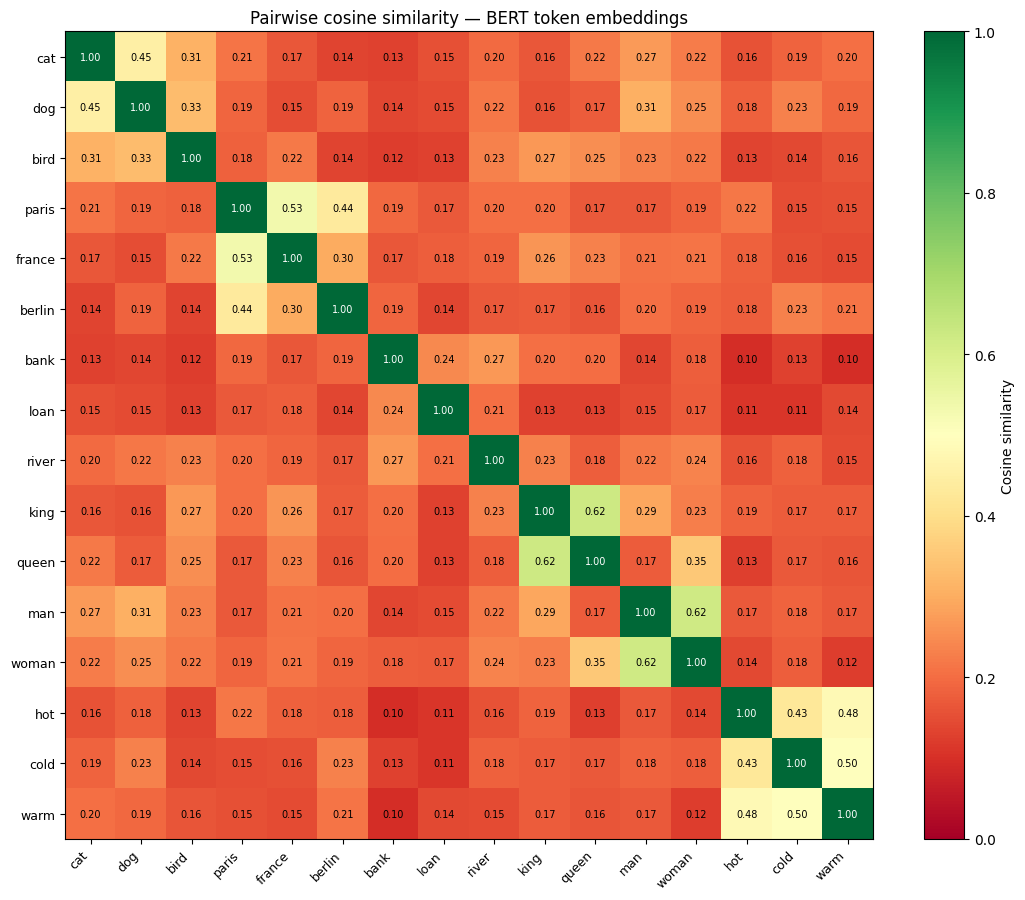

In [17]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

words = list(word_embeddings.keys())
emb_matrix = np.stack(list(word_embeddings.values()))
sim_matrix  = cos_sim(emb_matrix)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(words, fontsize=9)

for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if sim_matrix[i,j] > 0.97 else 'black')

plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Pairwise cosine similarity — BERT token embeddings', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Find the most and least similar word pairs (excluding self-similarity on the diagonal)
pairs = []
for i in range(len(words)):
    for j in range(i+1, len(words)):
        pairs.append((sim_matrix[i,j], words[i], words[j]))

pairs.sort(reverse=True)

print("Top 5 most similar word pairs:")
for sim, w1, w2 in pairs[:5]:
    print(f"  {w1:<10} ↔  {w2:<10}  similarity: {sim:.4f}")

print()
print("Bottom 5 least similar word pairs:")
for sim, w1, w2 in pairs[-5:]:
    print(f"  {w1:<10} ↔  {w2:<10}  similarity: {sim:.4f}")

print()
print("hot' and 'cold' despite being antonyms, appear in identical contexts in training data.")

Top 5 most similar word pairs:
  king       ↔  queen       similarity: 0.6223
  man        ↔  woman       similarity: 0.6184
  paris      ↔  france      similarity: 0.5330
  cold       ↔  warm        similarity: 0.4962
  hot        ↔  warm        similarity: 0.4822

Bottom 5 least similar word pairs:
  bird       ↔  bank        similarity: 0.1230
  loan       ↔  hot         similarity: 0.1128
  loan       ↔  cold        similarity: 0.1100
  bank       ↔  hot         similarity: 0.0966
  bank       ↔  warm        similarity: 0.0953

hot' and 'cold' despite being antonyms, appear in identical contexts in training data.


## Vector arithmetic — king − man + woman ≈ queen

The famous demonstration of embedding quality is vector arithmetic. In well-trained embedding spaces, analogical relationships are encoded geometrically — the vector from "man" to "king" represents something like "royalty", and adding that to "woman" lands near "queen".

This works because words that appear in similar contexts end up with similar vectors. "King" and "queen" appear in similar contexts to each other, and "man" and "woman" appear in similar contexts to each other, so the offset between the two pairs is consistent across the training distribution.


In [19]:
# Vector arithmetic using BERT token embeddings
# Extend our vocabulary to include the words needed for analogy tasks

analogy_words = ["king", "queen", "man", "woman",
                 "lisbon", "portugal", "berlin", "germany",
                 "doctor", "nurse", "engineer", "teacher",
                 "hot", "cold", "warm", "cool"]

# Get embeddings for all analogy words using the same BERT lookup as above
word_emb = {word: get_word_embedding(word, bert_tokenizer, bert_model)
            for word in analogy_words}

def analogy(a, b, c, word_emb, top_k=5):
    """
    Solve: a is to b as c is to ?
    Computed as: vector(b) - vector(a) + vector(c)
    Returns the top_k closest words from our vocabulary.
    """
    target = word_emb[b] - word_emb[a] + word_emb[c]
    target = target / np.linalg.norm(target)

    sims = {}
    for w, emb in word_emb.items():
        if w not in [a, b, c]:
            emb_norm = emb / np.linalg.norm(emb)
            sims[w] = float(np.dot(target, emb_norm))

    return sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_k]

# king - man + woman = ?
print("king − man + woman = ?")
results = analogy("man", "king", "woman", word_emb)
for word, sim in results:
    print(f"  {word:<15} similarity: {sim:.4f}")

print()

# lisbon - portugal + germany = ?
print("lisbon − portugal + germany = ?")
results = analogy("portugal", "lisbon", "germany", word_emb)
for word, sim in results:
    print(f"  {word:<15} similarity: {sim:.4f}")

king − man + woman = ?
  queen           similarity: 0.6286
  nurse           similarity: 0.2305
  teacher         similarity: 0.2205
  doctor          similarity: 0.2135
  portugal        similarity: 0.1760

lisbon − portugal + germany = ?
  berlin          similarity: 0.4220
  cold            similarity: 0.2037
  man             similarity: 0.2018
  woman           similarity: 0.1843
  teacher         similarity: 0.1741


## Visualizing the embedding space

Embedding vectors are high-dimensional — 384 dimensions in our model. We cannot visualise 384 dimensions directly, but as know we can use TSNE to project the embeddings down to 2 dimensions.

The resulting plot shows how the model has organised semantic concepts in space — related concepts should cluster together.


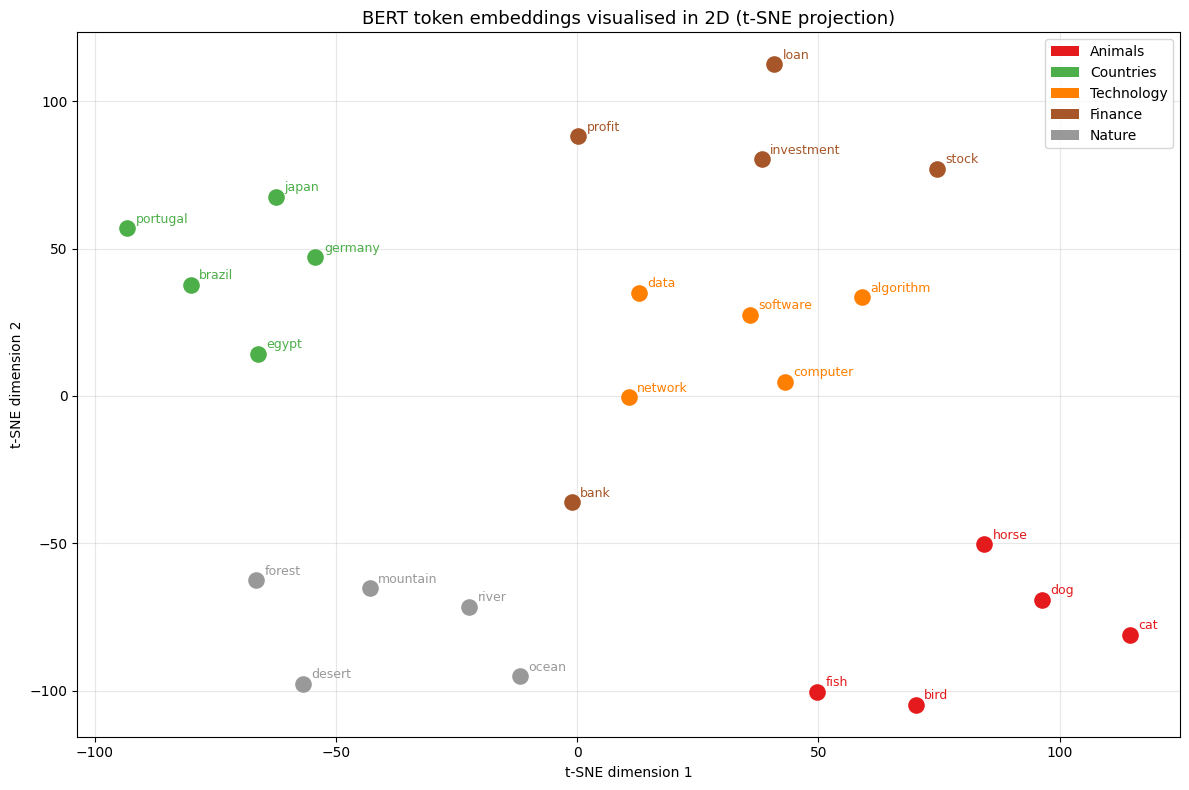

In [20]:
# Visualize the embedding space using t-SNE
# t-SNE preserves LOCAL structure —
# words that are close together in 768-dimensional space stay close in 2D.

from sklearn.manifold import TSNE

viz_words = {
    "Animals":    ["cat", "dog", "bird", "fish", "horse"],
    "Countries":  ["portugal", "germany", "japan", "brazil", "egypt"],
    "Technology": ["computer", "software", "algorithm", "network", "data"],
    "Finance":    ["bank", "loan", "investment", "stock", "profit"],
    "Nature":     ["river", "mountain", "forest", "ocean", "desert"],
}

all_words  = [w for words in viz_words.values() for w in words]
all_labels = [cat for cat, words in viz_words.items() for _ in words]
all_embeddings = np.stack([
    get_word_embedding(w, bert_tokenizer, bert_model) for w in all_words
])

# t-SNE reduces 768 dimensions → 2 dimensions
# perplexity controls how many neighbours each point considers — use small value
tsne = TSNE(n_components=2, perplexity=8, random_state=42,
            n_iter=1000, learning_rate='auto', init='pca')
coords_2d = tsne.fit_transform(all_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Set1(np.linspace(0, 0.9, len(viz_words)))
color_map = dict(zip(viz_words.keys(), colors))

for i, (word, label) in enumerate(zip(all_words, all_labels)):
    x, y = coords_2d[i]
    ax.scatter(x, y, color=color_map[label], s=120, zorder=3)
    ax.annotate(word, (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=9, color=color_map[label])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cat], label=cat) for cat in viz_words]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

ax.set_title('BERT token embeddings visualised in 2D (t-SNE projection)', fontsize=13)
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Context-independent vs contextual embeddings

There is a distinction between:

**Context-independent embeddings** — the initial token embeddings looked up from the embedding table before any transformer processing. The vector for the token "bank" is identical regardless of context. This is the starting point before any transformer layer has been applied.

**Contextual embeddings** — the hidden states produced after the token representations have been updated by the attention mechanism across multiple transformer layers. At this stage, the vector for "bank" in "the river bank flooded" is measurably different from the vector for "bank" in "the savings bank collapsed" — because the attention mechanism has incorporated information from the surrounding tokens into each token's representation.

This distinction is fundamental to understanding why transformers are so much more powerful than simple lookup-based approaches. In this section we extract both types of embedding from a pre-trained BERT model and demonstrate the difference directly.



## Initial (context-independent) embeddings

The embedding table in BERT stores one 768-dimensional vector for each of its ~30,000 tokens. These vectors are context-independent — the same token always retrieves the same vector, regardless of surrounding context.

Let us extract the initial embedding for the token "bank" and verify that it is identical across different contexts.


In [21]:
# Two sentences with 'bank' in completely different senses
sentence_financial = "I deposited money at the savings bank yesterday."
sentence_river     = "The river bank was flooded after heavy rainfall."
sentence_neutral   = "The bank was nearby."

def get_token_embedding_at_layer(sentence, target_word, tokenizer, model, layer=0):
    """
    Extract the embedding of target_word from a specific transformer layer.
    layer=0 returns the initial context-independent embedding.
    layer=12 returns the final contextual embedding (for BERT base).
    """
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        outputs = model(**inputs)
    # Because we loaded the model with output_hidden_states=True,
    # the outputs object contains the intermediate representations from every layer
    # hidden_states[0] = embedding layer (context-independent)
    # hidden_states[1..12] = after each transformer layer
    hidden_states = outputs.hidden_states

    # Find the position of the target word token
    target_positions = [i for i, t in enumerate(tokens)
                        if target_word.lower() in t.lower()]

    if not target_positions:
        print(f"Warning: '{target_word}' not found in tokens: {tokens}")
        return None, tokens

    pos = target_positions[0]
    embedding = hidden_states[layer][0][pos].cpu().numpy()
    return embedding, tokens

# Extract initial (layer 0) embeddings for 'bank' in each context
emb_financial_l0, toks_financial = get_token_embedding_at_layer(
    sentence_financial, "bank", bert_tokenizer, bert_model, layer=0)
emb_river_l0, toks_river = get_token_embedding_at_layer(
    sentence_river, "bank", bert_tokenizer, bert_model, layer=0)
emb_neutral_l0, toks_neutral = get_token_embedding_at_layer(
    sentence_neutral, "bank", bert_tokenizer, bert_model, layer=0)

print("Sentences and their tokenization:")
print(f"Financial: {toks_financial}")
print(f"River:     {toks_river}")
print(f"Neutral:   {toks_neutral}")
print()

# Compute similarities between initial embeddings
sim_fin_riv_l0 = float(cosine_similarity(
    emb_financial_l0.reshape(1,-1), emb_river_l0.reshape(1,-1))[0][0])
sim_fin_neu_l0 = float(cosine_similarity(
    emb_financial_l0.reshape(1,-1), emb_neutral_l0.reshape(1,-1))[0][0])

print("Initial embedding (layer 0 — context-independent):")
print(f"  Similarity(financial bank, river bank):   {sim_fin_riv_l0:.6f}")
print(f"  Similarity(financial bank, neutral bank): {sim_fin_neu_l0:.6f}")


Sentences and their tokenization:
Financial: ['[CLS]', 'i', 'deposited', 'money', 'at', 'the', 'savings', 'bank', 'yesterday', '.', '[SEP]']
River:     ['[CLS]', 'the', 'river', 'bank', 'was', 'flooded', 'after', 'heavy', 'rainfall', '.', '[SEP]']
Neutral:   ['[CLS]', 'the', 'bank', 'was', 'nearby', '.', '[SEP]']

Initial embedding (layer 0 — context-independent):
  Similarity(financial bank, river bank):   0.935905
  Similarity(financial bank, neutral bank): 0.945321


Because the positional embedding is different at each position, the layer 0 vector for "bank" is not identical across the three sentences — it already carries position information. This is why similarity is 0.935 rather than 1.0.

## Contextual embeddings from a transformer

Now let us extract embeddings **after** all 12 transformer layers have processed the sequence. At this point, the attention mechanism has updated each token's representation based on every other token in the sequence — "bank" in the financial context has attended to "savings", "deposited", and "money"; "bank" in the river context has attended to "river", "flooded", and "rainfall".

The resulting vectors should now be measurably different. First check the number of layers, to make sure we get the embedding from the last layer.


In [22]:
bert_model.config.num_hidden_layers

12

In [23]:
# Extract final (layer 12) contextual embeddings for 'bank' in each context
emb_financial_l12, _ = get_token_embedding_at_layer(
    sentence_financial, "bank", bert_tokenizer, bert_model, layer=12)
emb_river_l12, _ = get_token_embedding_at_layer(
    sentence_river, "bank", bert_tokenizer, bert_model, layer=12)
emb_neutral_l12, _ = get_token_embedding_at_layer(
    sentence_neutral, "bank", bert_tokenizer, bert_model, layer=12)

# Compute similarities between final contextual embeddings
sim_fin_riv_l12 = float(cosine_similarity(
    emb_financial_l12.reshape(1,-1), emb_river_l12.reshape(1,-1))[0][0])
sim_fin_neu_l12 = float(cosine_similarity(
    emb_financial_l12.reshape(1,-1), emb_neutral_l12.reshape(1,-1))[0][0])
sim_riv_neu_l12 = float(cosine_similarity(
    emb_river_l12.reshape(1,-1), emb_neutral_l12.reshape(1,-1))[0][0])

print("Contextual embedding (layer 12 — after full transformer processing):")
print(f"  Similarity(financial bank, river bank):   {sim_fin_riv_l12:.6f}  ← now distinct")
print(f"  Similarity(financial bank, neutral bank): {sim_fin_neu_l12:.6f}")
print(f"  Similarity(river bank, neutral bank):     {sim_riv_neu_l12:.6f}")
print()
print("The contextual embeddings are now different — the attention mechanism has")
print("incorporated information from surrounding words into each 'bank' token.")

Contextual embedding (layer 12 — after full transformer processing):
  Similarity(financial bank, river bank):   0.468519  ← now distinct
  Similarity(financial bank, neutral bank): 0.689555
  Similarity(river bank, neutral bank):     0.552019

The contextual embeddings are now different — the attention mechanism has
incorporated information from surrounding words into each 'bank' token.


## How similarity evolves across layers

The disambiguation does not happen all at once — it develops gradually as the token representations pass through successive transformer layers. Let us track how the similarity between the financial and river "bank" embeddings changes from layer 0 (context-independent) through to layer 12 (fully contextualized).


In [24]:
# Track cosine similarity between the two 'bank' embeddings across all 13 layers
# (layer 0 = initial embedding, layers 1-12 = after each transformer block)

similarities_across_layers = []

for layer_idx in range(13):  # 0 through 12
    emb_fin, _ = get_token_embedding_at_layer(
        sentence_financial, "bank", bert_tokenizer, bert_model, layer=layer_idx)
    emb_riv, _ = get_token_embedding_at_layer(
        sentence_river, "bank", bert_tokenizer, bert_model, layer=layer_idx)

    sim = float(cosine_similarity(
        emb_fin.reshape(1,-1), emb_riv.reshape(1,-1))[0][0])
    similarities_across_layers.append(sim)
    print(f"Layer {layer_idx:2d}:  similarity = {sim:.6f}")

Layer  0:  similarity = 0.935905
Layer  1:  similarity = 0.666483
Layer  2:  similarity = 0.610322
Layer  3:  similarity = 0.599446
Layer  4:  similarity = 0.565400
Layer  5:  similarity = 0.528080
Layer  6:  similarity = 0.536566
Layer  7:  similarity = 0.491027
Layer  8:  similarity = 0.492531
Layer  9:  similarity = 0.473010
Layer 10:  similarity = 0.495619
Layer 11:  similarity = 0.535611
Layer 12:  similarity = 0.468519


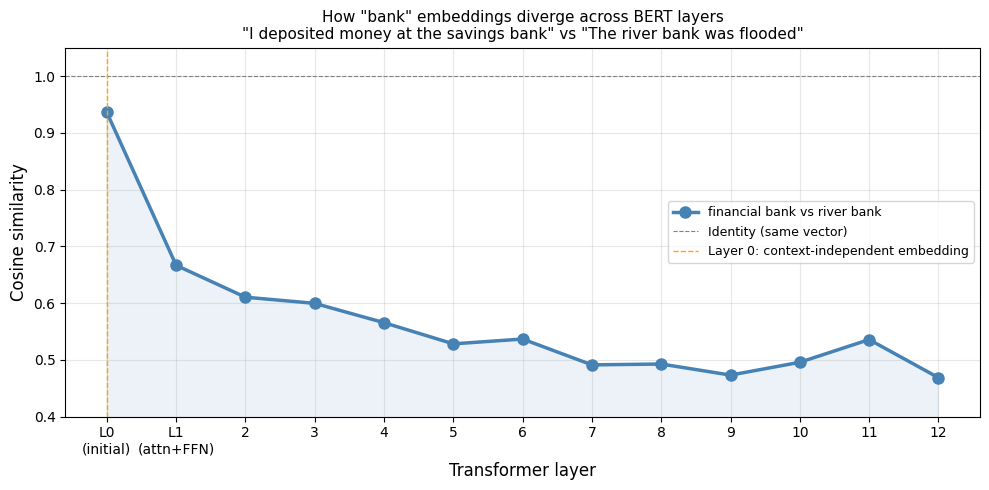


Layer  0 (initial):    similarity = 0.935905  — very similar vectors, difference in positional encoding
Layer 12 (final):      similarity = 0.468519  — clearly disambiguated

The disambiguation develops progressively across layers as attention
updates each token's representation based on surrounding context.


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

layers = list(range(13))
ax.plot(layers, similarities_across_layers, 'o-', color='steelblue',
        linewidth=2.5, markersize=8, label='financial bank vs river bank')
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, label='Identity (same vector)')
ax.axvline(x=0, color='orange', linestyle='--', linewidth=1,
           label='Layer 0: context-independent embedding')

ax.fill_between(layers, similarities_across_layers, alpha=0.1, color='steelblue')

ax.set_xlabel('Transformer layer', fontsize=12)
ax.set_ylabel('Cosine similarity', fontsize=12)
ax.set_title('How "bank" embeddings diverge across BERT layers\n'
             '"I deposited money at the savings bank" vs "The river bank was flooded"',
             fontsize=11)
ax.set_xticks(layers)
ax.set_xticklabels([f'L{i}\n({"initial" if i==0 else "attn+FFN"})' if i <= 1
                    else str(i) for i in layers])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()

print()
print(f"Layer  0 (initial):    similarity = {similarities_across_layers[0]:.6f}  — very similar vectors, difference in positional encoding")
print(f"Layer 12 (final):      similarity = {similarities_across_layers[12]:.6f}  — clearly disambiguated")
print()
print("The disambiguation develops progressively across layers as attention")
print("updates each token's representation based on surrounding context.")

# Text generation and sampling parameters


An LLM generates text one token at a time and at each step:
1. The full context (prompt + tokens generated so far) is passed through the transformer
2. The final hidden state is multiplied by the unembedding matrix → raw logits
3. Temperature scaling is applied to the logits
4. Softmax converts scaled logits into a probability distribution
5. A token is sampled from the distribution
6. That token is appended to the context and the process repeats

In this section we use GPT-2 — a small (117M parameter) publicly available model — to observe how the three main sampling parameters affect the output:
- **Temperature** — sharpens or flattens the probability distribution
- **max_new_tokens** — hard limit on response length
- **top_p** — nucleus sampling, restricts candidates to a cumulative probability threshold

## Loading GPT-2

GPT-2 has the same architectural family as GPT-3 and GPT-4. It is much smaller (124M parameters vs 175B for GPT-3) but demonstrates all the same generation mechanics.

The model downloads automatically on first run. On subsequent runs it is loaded from local cache. Each parameter is stored as a 32-bit floating point number by default, which takes 4 bytes of memory: 124M parameters  ×  4 bytes  ~500 MB.

In [26]:
# GPT-2: 117M parameters, 12 transformer layers, 768-dimensional embeddings
# Vocabulary: ~50,257 tokens, context window: 1,024 tokens

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model     = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

# GPT-2 does not have a pad token by default — set it to eos_token
tokenizer.pad_token = tokenizer.eos_token

print(f"GPT-2 loaded on {device}")
print(f"Parameters:        {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary size:   {tokenizer.vocab_size:,}")
print(f"Embedding dim:     {model.config.n_embd}")
print(f"Transformer layers:{model.config.n_layer}")
print(f"Attention heads:   {model.config.n_head}")
print(f"Context window:    {model.config.n_positions}")

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded on cpu
Parameters:        124,439,808
Vocabulary size:   50,257
Embedding dim:     768
Transformer layers:12
Attention heads:   12
Context window:    1024


## A simple generation function

In [27]:
def generate(prompt, max_new_tokens=80, temperature=1.0, top_p=1.0,
             do_sample=True, num_return_sequences=1, seed=42):
    """
    Generate text from a prompt using GPT-2.

    Parameters
    ----------
    prompt            : str   — the input text
    max_new_tokens    : int   — maximum number of tokens to generate
    temperature       : float — controls randomness (0 = deterministic, 1 = default)
    top_p             : float — nucleus sampling threshold (1.0 = disabled)
    do_sample         : bool  — if False, always picks the most probable token
    num_return_sequences : int — how many independent completions to generate
    seed              : int   — random seed for reproducibility
    """
    torch.manual_seed(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature if do_sample else 1.0,
            top_p=top_p,
            do_sample=do_sample,
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id,
        )

    results = []
    for out in outputs:
        # Return only the newly generated tokens (not the prompt)
        new_tokens = out[inputs['input_ids'].shape[1]:]
        results.append(tokenizer.decode(new_tokens, skip_special_tokens=True))

    return results[0] if num_return_sequences == 1 else results

# Quick test
prompt = "The history of artificial intelligence began"
result = generate(prompt, max_new_tokens=30, temperature=0.7)
print(f"Prompt: '{prompt}'")
print(f"Completion: '{result}'")

Prompt: 'The history of artificial intelligence began'
Completion: ' with Watson first appearing in the late 1950s, when Google began using the platform to create a computer-aided learning system. The company had no'


## Effect of temperature

Temperature is applied to the logits **before** Softmax. Dividing by a small temperature amplifies the differences between logit values, concentrating probability mass on the most likely tokens. Dividing by a large temperature flattens the distribution, giving lower-probability tokens a better chance.

- **temperature = 0** → always picks the single most probable token (deterministic)
- **temperature = 0.5** → focused, conservative, low variation
- **temperature = 1.0** → default, samples from the unmodified distribution
- **temperature > 1.0** → creative but risks incoherence

We use the same seed for each run so any differences in output are attributable purely to temperature, not to random variation.


In [28]:
prompt = "Once upon a time in a land far away, there lived"

temperatures = [0.0, 0.3, 0.7, 1.0, 1.3]

print(f"Prompt: '{prompt}'\n")
print("=" * 70)

for temp in temperatures:
    if temp == 0.0:
        completion = generate(prompt, max_new_tokens=60, temperature=1.0,
                              do_sample=False, seed=42)
        label = "temperature=0.0 (always most probable token)"
    else:
        completion = generate(prompt, max_new_tokens=60, temperature=temp,
                              do_sample=True, seed=42)
        label = f"temperature={temp}"

    print(f"\n[{label}]")
    print(prompt + completion)
    print("-" * 70)

Prompt: 'Once upon a time in a land far away, there lived'


[temperature=0.0 (always most probable token)]
Once upon a time in a land far away, there lived a man who was a man of great wealth and great power. He was a man of great wealth and great power. He was a man of great wealth and great power. He was a man of great wealth and great power. He was a man of great wealth and great power. He was a
----------------------------------------------------------------------

[temperature=0.3]
Once upon a time in a land far away, there lived a man who was a man of great renown, and who was known as a man of great power. He was a man of great renown, and he was known as a man of great power. He was a man of great renown, and he was known as a man of great power. He
----------------------------------------------------------------------

[temperature=0.7]
Once upon a time in a land far away, there lived a king, a god, a king, who loved to fight, and who was a true warrior. The king's father was

## Effect of max_new_tokens

`max_new_tokens` sets a hard ceiling on the number of tokens the model can generate. It does not control response quality or coherence — it simply stops generation once the limit is reached. If the model reaches the limit mid-sentence the output is cut off abruptly.


In [29]:
prompt = "Explain what a neural network is in simple terms:"

token_limits = [20, 50, 100, 200]

print(f"Prompt: '{prompt}'\n")

for limit in token_limits:
    completion = generate(prompt, max_new_tokens=limit, temperature=0.7, seed=42)
    n_tokens = len(tokenizer.encode(completion))
    print(f"\n[max_new_tokens={limit}, actual tokens generated={n_tokens}]")
    print(prompt + completion)
    if n_tokens >= limit - 2:
        print("  ⚠️  Response appears truncated — increase max_new_tokens")
    print("-" * 70)

Prompt: 'Explain what a neural network is in simple terms:'


[max_new_tokens=20, actual tokens generated=20]
Explain what a neural network is in simple terms: a neural network is a computer program operating on a computer, i.e. a neural network can
  ⚠️  Response appears truncated — increase max_new_tokens
----------------------------------------------------------------------

[max_new_tokens=50, actual tokens generated=50]
Explain what a neural network is in simple terms: a neural network is a computer program operating on a computer, i.e. a neural network can be an object of interest to a human.

The problem with this definition of a neural network is that it does not really say anything about how
  ⚠️  Response appears truncated — increase max_new_tokens
----------------------------------------------------------------------

[max_new_tokens=100, actual tokens generated=100]
Explain what a neural network is in simple terms: a neural network is a computer program operating on a compu

## Top-p nucleus sampling

**Top-p (nucleus sampling)** filters the candidate tokens before sampling, but after temperature setting. The model sorts all tokens by probability (highest to lowest) and keeps the smallest set whose cumulative probability reaches `p`. Only tokens in this set are eligible for sampling — the rest are discarded.

The key difference from temperature:
- **Temperature** reshapes the entire distribution — it changes the probabilities of all tokens
- **Top-p** truncates the distribution — it simply removes low-probability tokens from consideration

When the model is confident about the next token, the top few tokens already account for most of the probability mass, so the nucleus is small and the output is focused. When the model is uncertain, many tokens share probability mass, the nucleus is larger, and the output is more varied.

`top_p=1.0` disables nucleus sampling (all tokens eligible). `top_p=0.5` keeps only the tokens that together account for 50% of the probability mass.


In [30]:
prompt = "The most important discovery in modern physics was"

top_p_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

print(f"Prompt: '{prompt}'  (temperature=1.0 fixed)\n")
print("=" * 70)

for top_p in top_p_values:
    completion = generate(prompt, max_new_tokens=60, temperature=1.0,
                          top_p=top_p, do_sample=True, seed=42)
    print(f"\n[top_p={top_p}]")
    print(prompt + completion)
    print("-" * 70)

Prompt: 'The most important discovery in modern physics was'  (temperature=1.0 fixed)


[top_p=0.1]
The most important discovery in modern physics was that the universe is a very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very small, very
----------------------------------------------------------------------

[top_p=0.3]
The most important discovery in modern physics was that the Earth's magnetic field is not the same as the Earth's magnetic field. The Earth's magnetic field is not the same as the Earth's magnetic field.

In fact, the Earth's magnetic field is not the same as the Earth's magnetic field. The Earth's magnetic field is
----------------------------------------------------------------------

[top_p=0.5]
The most important discovery in modern physics was that there was a large-scale effect on the distribution of the light

## Visualizing how temperature changes the probability distribution

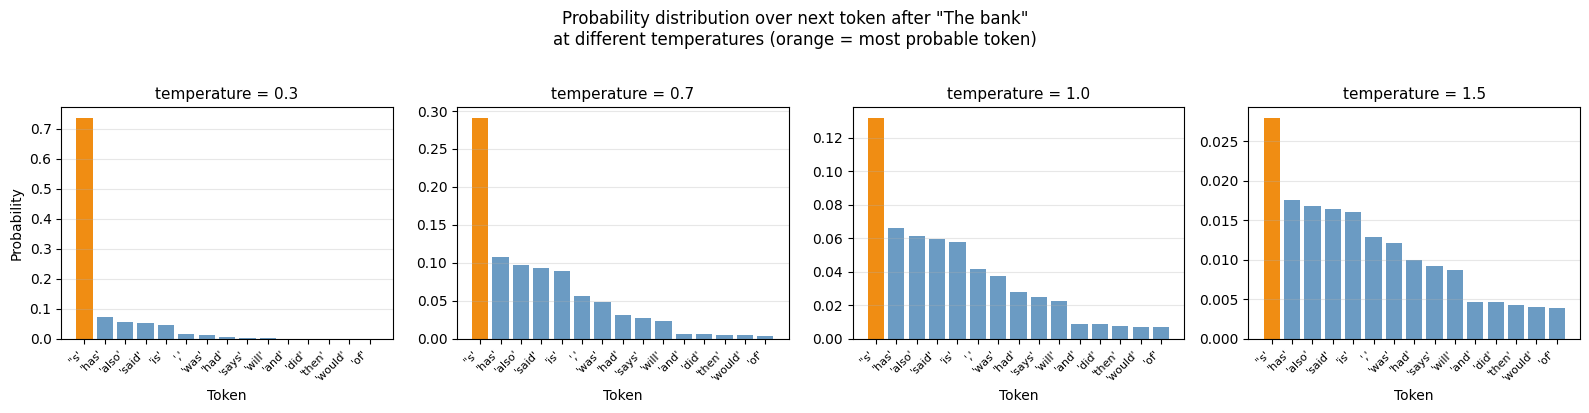

In [31]:
prompt = "The bank"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

# .logits[0, -1, :] extracts 1D tensor of 50,257 raw logit scores
with torch.no_grad():
    logits = model(**inputs).logits[0, -1, :]

# Get top 15 token probabilities at different temperatures
top_k = 15
top_indices = torch.topk(logits, top_k).indices.tolist()
top_tokens  = [tokenizer.decode([i]).strip() for i in top_indices]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
temperatures_plot = [0.3, 0.7, 1.0, 1.5]

for ax, temp in zip(axes, temperatures_plot):
    scaled_logits = logits / temp
    probs = torch.softmax(scaled_logits, dim=-1)
    top_probs = [probs[i].item() for i in top_indices]

    bars = ax.bar(range(top_k), top_probs, color='steelblue', alpha=0.8)
    ax.set_xticks(range(top_k))
    ax.set_xticklabels([f"'{t}'" for t in top_tokens],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(f'temperature = {temp}', fontsize=11)
    ax.set_ylabel('Probability' if temp == 0.3 else '')
    ax.set_xlabel('Token')
    ax.grid(True, alpha=0.3, axis='y')

    # Annotate the top token
    ax.bar([0], [top_probs[0]], color='darkorange', alpha=0.9)

plt.suptitle(f'Probability distribution over next token after "{prompt}"\n'
             'at different temperatures (orange = most probable token)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


- At temperature=0.3, one token dominates — the distribution is sharp.
- At temperature=1.5, probabilities spread across many tokens — the distribution is more uniform.

Temperature does not change which token is most probable — only how dominant it is.

## Comparing temperature and top-p

In [32]:
# Side-by-side comparison: same prompt, different parameter combinations
prompt = "In the future, artificial intelligence will"

configs = [
    {"label": "temp=0",                    "temperature": 1.0, "top_p": 1.0, "do_sample": False},
    {"label": "Low temp (temp=0.3)",       "temperature": 0.3, "top_p": 1.0, "do_sample": True},
    {"label": "Default (temp=1.0)",        "temperature": 1.0, "top_p": 1.0, "do_sample": True},
    {"label": "High temp (temp=1.3)",      "temperature": 1.3, "top_p": 1.0, "do_sample": True},
    {"label": "Top-p p=0.5",               "temperature": 1.0, "top_p": 0.5, "do_sample": True},
    {"label": "Top-p p=0.9",               "temperature": 1.0, "top_p": 0.9, "do_sample": True},
    {"label": "Combined temp=0.7, p=0.9",  "temperature": 0.7, "top_p": 0.9, "do_sample": True},
]

print(f"Prompt: '{prompt}'\n")

for cfg in configs:
    completion = generate(
        prompt,
        max_new_tokens=50,
        temperature=cfg["temperature"],
        top_p=cfg["top_p"],
        do_sample=cfg["do_sample"],
        seed=42
    )
    print(f"[{cfg['label']}]")
    print(f"  {prompt}{completion}")
    print()

Prompt: 'In the future, artificial intelligence will'

[temp=0]
  In the future, artificial intelligence will be able to do things like search for information about people, and to do things like search for information about people.

"We're going to see a lot of things that are going to be very interesting in the future," he said. "

[Low temp (temp=0.3)]
  In the future, artificial intelligence will be able to learn from the past and apply that knowledge to the future.

The future is not just about AI. It's also about the future of the human race.

The future is not just about AI. It's also about

[Default (temp=1.0)]
  In the future, artificial intelligence will be designed to work better at certain tasks more quickly than humans. For example, machines would be able to run for longer periods of time, not because they were smarter than humans, but because their skills at such tasks exceeded human capacity. The current state

[High temp (temp=1.3)]
  In the future, artificial intelligen

## Prompting a base model — what actually happens

**Base model** — trained purely on next-token prediction over a massive corpus. Extraordinarily knowledgeable and fluent, but never explicitly trained to follow instructions. When given an instruction, it treats it as text to be continued statistically — it may complete the instruction rather than execute it.

**Instruct model** — the base model after supervised fine-tuning on instruction-response pairs, followed by RLHF. The same underlying knowledge, but trained to interpret instructions and generate helpful responses.

GPT-2 is small enough to run locally but old enough that it predates modern instruction tuning.

In [33]:
# Reload GPT-2 as our base model
tokenizer_base = GPT2Tokenizer.from_pretrained("gpt2")
model_base     = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model_base.eval()
tokenizer_base.pad_token = tokenizer_base.eos_token

def generate_base(prompt, max_new_tokens=80, temperature=0.7, top_p=0.9, seed=42):
    torch.manual_seed(seed)
    inputs = tokenizer_base(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_base.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer_base.eos_token_id,
        )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer_base.decode(new_tokens, skip_special_tokens=True)

# Instruction-style prompts given to a base model
instruction_prompts = [
    "Summarize the following text in one sentence:",
    "Translate the following English text to Portuguese: Hello, how are you?",
    "What is the capital of Japan?",
    "Write a Python function that sorts a list.",
    "Explain what machine learning is.",
]

print("Giving instruction prompts to a BASE model (GPT-2):")
print("=" * 70)

for prompt in instruction_prompts:
    completion = generate_base(prompt, max_new_tokens=60, seed=42)
    print(f"\nPrompt:     '{prompt}'")
    print(f"Completion: '{completion.strip()}'")
    print("-" * 70)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Giving instruction prompts to a BASE model (GPT-2):

Prompt:     'Summarize the following text in one sentence:'
Completion: '"He is the master of the world. And he is the master of the mind, and the master of the body. He is the master of all things. He is the master of the universe. He is the master of the soul. He is the master of the heart. He'
----------------------------------------------------------------------

Prompt:     'Translate the following English text to Portuguese: Hello, how are you?'
Completion: 'I'm sorry to have to say this, but I'm really sorry. I'm sorry to say it. I'm sorry to say that I'm sorry. I'm sorry to say that I'm sorry. I'm sorry to say that I'm sorry. I'm sorry to say that I'm'
----------------------------------------------------------------------

Prompt:     'What is the capital of Japan?'
Completion: 'The capital of Japan is the capital of the world. And the capital of Japan is the capital of the world. The capital of Japan is the capital of the wo

# Key points



| Concept | Explanation |
|---|---|
| tokenization | Text is split into sub-word tokens (~4 chars each). Same semantic content requires different token counts in different languages — directly affecting cost and context window usage. |
| vocabulary | Fixed before training, token embeddings are learned during training. |
| embeddings | Dense vectors where semantic similarity = vector proximity. Encode co-occurrence patterns, not meaning — antonyms can be close in embedding space. |
| context-independence | Initial token embeddings are identical regardless of context. "Bank" has the same vector at layer 0 regardless of whether it means financial institution or river bank. |
| contextual embeddings | After passing through transformer layers, token representations diverge based on context. The disambiguation develops progressively across layers as attention updates each token's representation. |
| temperature | Applied to logits before Softmax. Low = sharp distribution (conservative). High = flat distribution (creative). |
| base model | Continues text statistically. Cannot follow instructions — treats them as text to be continued. |
